# Lab 21 - Colab Notebook: Finetuning - LoRa - QLoRa

**Họ và tên: Đặng Văn Minh**

**MSHV: 2A202600027**

Mục tiêu artifacts sau khi chạy end-to-end trên Colab T4:

| Artifact | Path |
|---|---|
| Rank metrics | `results/rank_experiment_summary.csv` |
| Per-run loss logs | `results/loss_history.csv` |
| Loss plot | `results/loss_curve.png` |
| Token length plot | `results/token_length_distribution.png` |
| Qualitative comparison | `results/qualitative_comparison.csv` |
| Report draft | `REPORT.md` |
| Links file | `LINKS.md` |
| Submission archive | `lab21_submission_artifacts.zip` |

Runtime khuyến nghị: Google Colab Free T4 16 GB. Vào `Runtime > Change runtime type > T4 GPU` trước khi chạy.

## 0. Configuration

In [8]:
# =========================
# Student / submission info
# =========================
STUDENT_NAME = "Đặng Văn Minh"
STUDENT_ID = "2A202600027"
GITHUB_REPO_URL = "https://github.com/DangMinh21/Day21-Track3-Finetuning-LLMs-LoRA-QLoRA"
COLAB_NOTEBOOK_URL = "https://github.com/DangMinh21/Day21-Track3-Finetuning-LLMs-LoRA-QLoRA/blob/main/Lab21_Llama32_LoRA_QLoRA_Colab.ipynb"

# =========================
# Experiment constants
# =========================
MODEL_NAME = "unsloth/Llama-3.2-3B-Instruct-bnb-4bit"
DATASET_NAME = "5CD-AI/Vietnamese-alpaca-gpt4-gg-translated"
SAMPLE_SIZE = 300
SEED = 42
MAX_SEQ_CAP = 1024
NUM_EPOCHS = 3
LEARNING_RATE = 2e-4
WARMUP_RATIO = 0.10
WEIGHT_DECAY = 0.01
TRAIN_BATCH_SIZE = 1
EVAL_BATCH_SIZE = 1
GRAD_ACCUM_STEPS = 8
PACKING = False

# T4 fallback: if OOM, lower this to 768 or 512, then rerun from dataset/tokenization.
# Keep at 1024 for the first attempt
FORCE_MAX_SEQ_LENGTH = None  # e.g. 768 or 512

# =========================
# Output / integrations
# =========================
MOUNT_DRIVE = False
DRIVE_OUTPUT_DIR = "/content/drive/MyDrive/lab21_finetune"
LOCAL_OUTPUT_DIR = "/content/lab21_finetune"

USE_WANDB = True
WANDB_PROJECT = "lab21-lora-rank-experiment"
WANDB_ENTITY = None  # usually None; set to your team/user only if needed

PUSH_TO_HUB = True  # set True after HF login works and adapters are trained
HF_USERNAME = "DangMinh21"
HF_REPO_PREFIX = "VinUni-lab21-Finetuning-w-LoRA-QLoRA"
HF_PRIVATE_REPOS = False

# Qualitative review can be edited after outputs are generated.
INTERACTIVE_QUALITATIVE_REVIEW = False

print("Configuration loaded")
print(f"Student: {STUDENT_NAME} ({STUDENT_ID})")
print(f"Model: {MODEL_NAME}")
print(f"Dataset: {DATASET_NAME} | sample size: {SAMPLE_SIZE}")
print(f"Ranks to train: qv-r16, qv-r8, qv-r32, qv-r64, all-r16")

Configuration loaded
Student: Đặng Văn Minh (2A202600027)
Model: unsloth/Llama-3.2-3B-Instruct-bnb-4bit
Dataset: 5CD-AI/Vietnamese-alpaca-gpt4-gg-translated | sample size: 300
Ranks to train: qv-r16, qv-r8, qv-r32, qv-r64, all-r16


## 1. Install Dependencies and Verify GPU

Cell cài đặt có thể mất vài phút trên Colab. Nếu Colab yêu cầu restart runtime sau install, restart rồi chạy lại từ cell này.

In [2]:
# Verify GPU before installing heavy dependencies.
!nvidia-smi

Thu May  7 07:57:26 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   37C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
%%capture
!pip install -q --upgrade pip
!pip install -q "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git"
!pip install -q --no-deps "trl>=0.12,<0.16" peft accelerate bitsandbytes
!pip install -q datasets matplotlib seaborn pandas numpy wandb huggingface_hub tabulate

In [4]:
import os
import gc
import json
import math
import time
import shutil
import textwrap
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

assert torch.cuda.is_available(), "GPU runtime is required. In Colab: Runtime > Change runtime type > GPU."
gpu_name = torch.cuda.get_device_name(0)
gpu_vram_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
print(f"GPU name: {gpu_name}")
print(f"GPU VRAM: {gpu_vram_gb:.2f} GB")
print(f"CUDA: {torch.version.cuda}")
print(f"PyTorch: {torch.__version__}")

if "T4" not in gpu_name:
    print("Note: spec targets T4. This GPU can still run, but report should state the actual GPU.")

GPU name: Tesla T4
GPU VRAM: 15.64 GB
CUDA: 12.8
PyTorch: 2.10.0+cu128


## 2. Output Directory, Drive, and Optional Logins

- Nếu muốn tránh mất checkpoint khi Colab disconnect, đặt `MOUNT_DRIVE=True` ở cell config.
- HF login cần thiết nếu model/repo yêu cầu token hoặc bạn muốn push adapter lên Hub.
- W&B login là bonus; nếu fail, notebook tự tắt W&B để training vẫn chạy.

In [9]:
if MOUNT_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUTPUT_DIR = Path(DRIVE_OUTPUT_DIR)
else:
    OUTPUT_DIR = Path(LOCAL_OUTPUT_DIR)

RESULTS_DIR = OUTPUT_DIR / "results"
ADAPTERS_DIR = OUTPUT_DIR / "adapters"
TRAINER_RUNS_DIR = OUTPUT_DIR / "trainer_runs"
REPORT_PATH = OUTPUT_DIR / "REPORT.md"
LINKS_PATH = OUTPUT_DIR / "LINKS.md"

for path in [OUTPUT_DIR, RESULTS_DIR, ADAPTERS_DIR, TRAINER_RUNS_DIR]:
    path.mkdir(parents=True, exist_ok=True)

print(f"OUTPUT_DIR: {OUTPUT_DIR}")
print(f"RESULTS_DIR: {RESULTS_DIR}")
print(f"ADAPTERS_DIR: {ADAPTERS_DIR}")

OUTPUT_DIR: /content/lab21_finetune
RESULTS_DIR: /content/lab21_finetune/results
ADAPTERS_DIR: /content/lab21_finetune/adapters


In [34]:
# Optional HuggingFace login. Run this if MODEL_NAME is gated or PUSH_TO_HUB=True.
# If you already set HF_TOKEN in Colab secrets/environment, notebook_login is not required.
from huggingface_hub import notebook_login

RUN_HF_LOGIN_NOW = True  # set True if you need to authenticate
if RUN_HF_LOGIN_NOW:
    notebook_login()
else:
    print("HF login skipped. Set RUN_HF_LOGIN_NOW=True if model download or Hub upload needs auth.")

In [12]:
# Optional W&B setup. The notebook falls back to report_to="none" if login fails.
WANDB_ENABLED = True
if USE_WANDB:
    try:
        import wandb
        login_ok = wandb.login(timeout=90)
        WANDB_ENABLED = bool(login_ok)
        print(f"W&B enabled: {WANDB_ENABLED}")
    except Exception as exc:
        WANDB_ENABLED = False
        print(f"W&B login failed; continuing without W&B. Reason: {type(exc).__name__}: {exc}")
else:
    print("W&B disabled by config.")

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice: (90 second timeout) 

2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: minhdv0201 (minhdv0201-ho-chi-minh-city-university-of-technology) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


W&B enabled: True


## 3. Dataset Preparation

Dataset mẫu Vietnamese Alpaca, sample 100-500 examples, format thành một field `text`, clean nhẹ, phân tích p95 token length, split 90/10 với seed 42.

In [13]:
# Import Unsloth before Transformers/TRL so its Colab optimizations and patches are active.
from unsloth import FastLanguageModel
from datasets import load_dataset
from transformers import AutoTokenizer

raw_full = load_dataset(DATASET_NAME, split="train")
print(f"Raw dataset rows: {len(raw_full):,}")
print(f"Raw columns: {raw_full.column_names}")

sample_n = min(SAMPLE_SIZE, len(raw_full))
raw = raw_full.shuffle(seed=SEED).select(range(sample_n))
print(f"Sampled rows with seed {SEED}: {len(raw):,}")
print("First raw sample:")
print(raw[0])

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
Unsloth: Could not find `steps_per_generation` in grpo_trainer
Unsloth: Could not find `generation_batch_size` in grpo_trainer


README.md:   0%|          | 0.00/95.0 [00:00<?, ?B/s]

alpaca_gpt4_data_vi.json:   0%|          | 0.00/102M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/52002 [00:00<?, ? examples/s]

Raw dataset rows: 52,002
Raw columns: ['input_en', 'input_vi', 'instruction_vi', 'output_vi', 'output_en', 'instruction_en']
Sampled rows with seed 42: 300
First raw sample:
{'input_en': '', 'input_vi': '', 'instruction_vi': 'Tạo ngân sách cơ bản cho người kiếm được 3500 đô la mỗi tháng.', 'output_vi': 'Dựa trên thu nhập 3500 USD mỗi tháng, đây là ngân sách cơ bản được đề xuất tuân theo quy tắc 50/30/20, phân bổ 50% thu nhập cho nhu cầu, 30% cho mong muốn và 20% cho tiết kiệm và trả nợ: - Tổng thu nhập hàng tháng: $3500 - Nhu cầu (50% thu nhập): $1750 - Nhà ở (tiền thuê nhà/thế chấp): $875 - Tiện ích (điện, nước, gas): $150 - Hàng tạp hóa: $300 - Bảo hiểm (sức khỏe, xe hơi, người thuê nhà, v.v. ): $200 - Đi lại (thanh toán ô tô, xăng, phương tiện công cộng): $225 - Mong muốn (30% thu nhập): $1050 - Ăn uống và giải trí: $300 - Chi phí mua sắm và cá nhân: $300 - Du lịch và sở thích: $250 - Linh tinh (đăng ký , thành viên): $200 - Tiết kiệm và trả nợ (20% thu nhập): $700 - Quỹ khẩn cấp: $

In [14]:
cols = raw.column_names
INSTRUCTION_COL = next((c for c in ["instruction", "instruction_vi", "prompt", "question"] if c in cols), None)
INPUT_COL = next((c for c in ["input", "input_vi", "context"] if c in cols), None)
OUTPUT_COL = next((c for c in ["output", "output_vi", "response", "answer"] if c in cols), None)
assert INSTRUCTION_COL and OUTPUT_COL, f"Could not detect instruction/output columns from: {cols}"

print("Detected columns:")
print(f"  instruction: {INSTRUCTION_COL}")
print(f"  input:       {INPUT_COL}")
print(f"  output:      {OUTPUT_COL}")

ALPACA_TEMPLATE_WITH_INPUT = """### Instruction:
{instruction}

### Input:
{input}

### Response:
{output}"""

ALPACA_TEMPLATE_NO_INPUT = """### Instruction:
{instruction}

### Response:
{output}"""

PROMPT_TEMPLATE_WITH_INPUT = """### Instruction:
{instruction}

### Input:
{input}

### Response:
"""

PROMPT_TEMPLATE_NO_INPUT = """### Instruction:
{instruction}

### Response:
"""

def normalize_text(value):
    if value is None:
        return ""
    return " ".join(str(value).strip().split())

def format_alpaca(example):
    instruction = normalize_text(example.get(INSTRUCTION_COL, ""))
    model_input = normalize_text(example.get(INPUT_COL, "")) if INPUT_COL else ""
    output = normalize_text(example.get(OUTPUT_COL, ""))
    if model_input:
        text = ALPACA_TEMPLATE_WITH_INPUT.format(instruction=instruction, input=model_input, output=output)
    else:
        text = ALPACA_TEMPLATE_NO_INPUT.format(instruction=instruction, output=output)
    return {
        "instruction": instruction,
        "input": model_input,
        "output": output,
        "text": text,
        "output_word_count": len(output.split()),
    }

formatted = raw.map(format_alpaca, remove_columns=raw.column_names)
print("Formatted sample:")
print(formatted[0]["text"][:900])

Detected columns:
  instruction: instruction_vi
  input:       input_vi
  output:      output_vi


Map:   0%|          | 0/300 [00:00<?, ? examples/s]

Formatted sample:
### Instruction:
Tạo ngân sách cơ bản cho người kiếm được 3500 đô la mỗi tháng.

### Response:
Dựa trên thu nhập 3500 USD mỗi tháng, đây là ngân sách cơ bản được đề xuất tuân theo quy tắc 50/30/20, phân bổ 50% thu nhập cho nhu cầu, 30% cho mong muốn và 20% cho tiết kiệm và trả nợ: - Tổng thu nhập hàng tháng: $3500 - Nhu cầu (50% thu nhập): $1750 - Nhà ở (tiền thuê nhà/thế chấp): $875 - Tiện ích (điện, nước, gas): $150 - Hàng tạp hóa: $300 - Bảo hiểm (sức khỏe, xe hơi, người thuê nhà, v.v. ): $200 - Đi lại (thanh toán ô tô, xăng, phương tiện công cộng): $225 - Mong muốn (30% thu nhập): $1050 - Ăn uống và giải trí: $300 - Chi phí mua sắm và cá nhân: $300 - Du lịch và sở thích: $250 - Linh tinh (đăng ký , thành viên): $200 - Tiết kiệm và trả nợ (20% thu nhập): $700 - Quỹ khẩn cấp: $200 - Quỹ hưu trí: $300 - Trả nợ (thẻ tín dụng, khoản vay sinh viên, v.v.): $200 Ngân sách này đóng vai trò là


In [15]:
# Light cleaning required by the rubric: remove empty rows, too-short outputs, and exact duplicate texts.
def keep_quality(example):
    return bool(example["instruction"]) and bool(example["output"]) and example["output_word_count"] >= 10

before_filter = len(formatted)
ds = formatted.filter(keep_quality)
seen = set()
keep_indices = []
for idx, item in enumerate(ds):
    if item["text"] not in seen:
        keep_indices.append(idx)
        seen.add(item["text"])
ds = ds.select(keep_indices)

print(f"Rows before cleaning: {before_filter}")
print(f"Rows after cleaning:  {len(ds)}")
assert len(ds) >= 100, "Spec expects 100-500 usable samples. Increase SAMPLE_SIZE or relax cleaning if needed."
print("Cleaned sample:")
print(ds[0]["text"][:900])

Filter:   0%|          | 0/300 [00:00<?, ? examples/s]

Rows before cleaning: 300
Rows after cleaning:  273
Cleaned sample:
### Instruction:
Tạo ngân sách cơ bản cho người kiếm được 3500 đô la mỗi tháng.

### Response:
Dựa trên thu nhập 3500 USD mỗi tháng, đây là ngân sách cơ bản được đề xuất tuân theo quy tắc 50/30/20, phân bổ 50% thu nhập cho nhu cầu, 30% cho mong muốn và 20% cho tiết kiệm và trả nợ: - Tổng thu nhập hàng tháng: $3500 - Nhu cầu (50% thu nhập): $1750 - Nhà ở (tiền thuê nhà/thế chấp): $875 - Tiện ích (điện, nước, gas): $150 - Hàng tạp hóa: $300 - Bảo hiểm (sức khỏe, xe hơi, người thuê nhà, v.v. ): $200 - Đi lại (thanh toán ô tô, xăng, phương tiện công cộng): $225 - Mong muốn (30% thu nhập): $1050 - Ăn uống và giải trí: $300 - Chi phí mua sắm và cá nhân: $300 - Du lịch và sở thích: $250 - Linh tinh (đăng ký , thành viên): $200 - Tiết kiệm và trả nợ (20% thu nhập): $700 - Quỹ khẩn cấp: $200 - Quỹ hưu trí: $300 - Trả nợ (thẻ tín dụng, khoản vay sinh viên, v.v.): $200 Ngân sách này đóng vai trò là


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/17.2M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/454 [00:00<?, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

Token length distribution:
  min=31 | p50=207 | p95=543 | p99=686 | max=713
  rounded p95=1024 | cap=1024 | chosen MAX_SEQ_LENGTH=1024


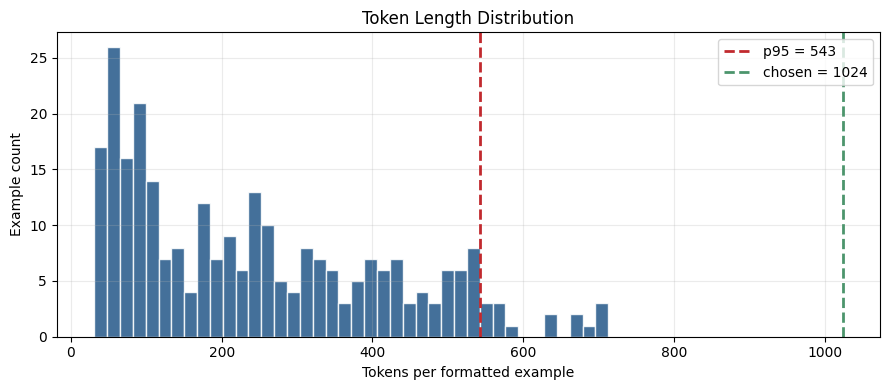

Saved token length plot: /content/lab21_finetune/results/token_length_distribution.png


In [16]:
# Token length analysis. This cell also saves the plot needed for the report.
tokenizer_for_length = AutoTokenizer.from_pretrained(MODEL_NAME)
if tokenizer_for_length.pad_token is None:
    tokenizer_for_length.pad_token = tokenizer_for_length.eos_token

lengths = [len(tokenizer_for_length.encode(x["text"], add_special_tokens=True)) for x in ds]
p50 = int(np.percentile(lengths, 50))
p95 = int(np.percentile(lengths, 95))
p99 = int(np.percentile(lengths, 99))
max_len_raw = max(lengths)

rounded_p95 = 1 << (max(p95, 256) - 1).bit_length()
MAX_SEQ_LENGTH = int(FORCE_MAX_SEQ_LENGTH or min(MAX_SEQ_CAP, rounded_p95))

print("Token length distribution:")
print(f"  min={min(lengths)} | p50={p50} | p95={p95} | p99={p99} | max={max_len_raw}")
print(f"  rounded p95={rounded_p95} | cap={MAX_SEQ_CAP} | chosen MAX_SEQ_LENGTH={MAX_SEQ_LENGTH}")

plt.figure(figsize=(9, 4))
plt.hist(lengths, bins=40, color="#235789", edgecolor="white", alpha=0.85)
plt.axvline(p95, color="#c1292e", linestyle="--", linewidth=2, label=f"p95 = {p95}")
plt.axvline(MAX_SEQ_LENGTH, color="#4c956c", linestyle="--", linewidth=2, label=f"chosen = {MAX_SEQ_LENGTH}")
plt.title("Token Length Distribution")
plt.xlabel("Tokens per formatted example")
plt.ylabel("Example count")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
length_plot_path = RESULTS_DIR / "token_length_distribution.png"
plt.savefig(length_plot_path, dpi=160, bbox_inches="tight")
plt.show()
print(f"Saved token length plot: {length_plot_path}")

In [17]:
# 90/10 train/eval split with fixed seed. Every run below uses exactly this split.
split = ds.train_test_split(test_size=0.10, seed=SEED)
train_ds = split["train"]
eval_ds = split["test"]
print(f"Train rows: {len(train_ds)}")
print(f"Eval rows:  {len(eval_ds)}")
print("Eval sample preview:")
print(eval_ds[0]["text"][:700])

Train rows: 245
Eval rows:  28
Eval sample preview:
### Instruction:
Phát triển cuộc trò chuyện giữa hai người về cuốn tiểu thuyết họ đang đọc.

### Response:
Người A: Này, bạn đã bắt đầu đọc cuốn tiểu thuyết "Giết con chim nhại" chưa? Người B: Ừ, tối qua tôi mới đọc xong mấy chương đầu. Nó thực sự tốt cho đến nay. Người A: Tôi đồng ý, thật ngạc nhiên khi tác giả Harper Lee tạo ra những nhân vật sống động và bối cảnh nhập vai đến vậy. Người B: Chắc chắn rồi, và tôi thích cách khám phá chủ đề phân biệt chủng tộc và thành kiến ​​qua con mắt của Scout, một nhân vật chính trẻ tuổi và ngây thơ. Người A: Đúng vậy. Giọng kể chuyện của nhân vật thực sự mang lại cảm giác ngây thơ nguyên sơ cho cốt truyện. Người B: Tôi cũng thấy thú vị khi cuốn tiểu th


## 4. Model, LoRA, Trainer, and Evaluation Helpers

Các helper dưới đây làm ba việc quan trọng:

1. Load base model 4-bit từ Unsloth.
2. Wrap LoRA theo run config (`q/v-only` hoặc `all-layers`).
3. Evaluate loss/perplexity bằng manual eval batch=1 để tránh OOM trên T4.

In [18]:
# FastLanguageModel was imported before Transformers in the dataset section.
from trl import SFTTrainer
from transformers import TrainingArguments, Trainer
import inspect
import trl
import transformers

print(f"trl version: {trl.__version__}")
print(f"transformers version: {transformers.__version__}")

# Compatibility patch for TRL/Transformers combinations where Trainer moved tokenizer -> processing_class.
try:
    import unsloth.models._utils as _u_utils
    _underlying_init = getattr(_u_utils, "_original_trainer_init", Trainer.__init__)
    if not getattr(_underlying_init, "_aliased", False):
        def _aliased_trainer_init(self, *args, **kwargs):
            if "tokenizer" in kwargs and "processing_class" not in kwargs:
                kwargs["processing_class"] = kwargs.pop("tokenizer")
            return _underlying_init(self, *args, **kwargs)
        _aliased_trainer_init._aliased = True
        _u_utils._original_trainer_init = _aliased_trainer_init
        if "tokenizer" not in inspect.signature(Trainer.__init__).parameters:
            _orig_trainer_init = Trainer.__init__
            def _trainer_init_compat(self, *args, **kwargs):
                if "tokenizer" in kwargs and "processing_class" not in kwargs:
                    kwargs["processing_class"] = kwargs.pop("tokenizer")
                return _orig_trainer_init(self, *args, **kwargs)
            _trainer_init_compat._aliased = True
            Trainer.__init__ = _trainer_init_compat
        print("Trainer compatibility patch applied.")
except Exception as exc:
    print(f"Trainer compatibility patch skipped: {type(exc).__name__}: {exc}")

try:
    from trl import SFTConfig
    HAS_SFTCONFIG = True
except ImportError:
    HAS_SFTCONFIG = False

TRAINING_ARGUMENT_PARAMS = inspect.signature(TrainingArguments.__init__).parameters
EVAL_KEY = "eval_strategy" if "eval_strategy" in TRAINING_ARGUMENT_PARAMS else "evaluation_strategy"
SFTTRAINER_PARAMS = inspect.signature(SFTTrainer.__init__).parameters
SUPPORTS_OLD_SFT_KWARGS = "dataset_text_field" in SFTTRAINER_PARAMS

print(f"HAS_SFTCONFIG: {HAS_SFTCONFIG}")
print(f"Evaluation arg key: {EVAL_KEY}")
print(f"SFTTrainer supports old dataset kwargs: {SUPPORTS_OLD_SFT_KWARGS}")

trl version: 0.15.2
transformers version: 5.5.0
Trainer compatibility patch applied.
HAS_SFTCONFIG: True
Evaluation arg key: eval_strategy
SFTTrainer supports old dataset kwargs: False


In [19]:
Q_V_MODULES = ["q_proj", "v_proj"]
ALL_LAYER_MODULES = ["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"]

RUN_SPECS = [
    {"run_id": "qv-r16", "target_label": "qv", "target_modules": Q_V_MODULES, "rank": 16, "alpha": 32, "required": True},
    {"run_id": "qv-r8", "target_label": "qv", "target_modules": Q_V_MODULES, "rank": 8, "alpha": 16, "required": True},
    {"run_id": "qv-r32", "target_label": "qv", "target_modules": Q_V_MODULES, "rank": 32, "alpha": 64, "required": False},
    {"run_id": "qv-r64", "target_label": "qv", "target_modules": Q_V_MODULES, "rank": 64, "alpha": 128, "required": True},
    {"run_id": "all-r16", "target_label": "all", "target_modules": ALL_LAYER_MODULES, "rank": 16, "alpha": 32, "required": False},
]

print("Run matrix:")
for spec in RUN_SPECS:
    print(f"  {spec['run_id']}: r={spec['rank']}, alpha={spec['alpha']}, targets={spec['target_label']}, required={spec['required']}")

Run matrix:
  qv-r16: r=16, alpha=32, targets=qv, required=True
  qv-r8: r=8, alpha=16, targets=qv, required=True
  qv-r32: r=32, alpha=64, targets=qv, required=False
  qv-r64: r=64, alpha=128, targets=qv, required=True
  all-r16: r=16, alpha=32, targets=all, required=False


In [20]:
def cleanup_cuda(verbose=True):
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    if verbose:
        allocated = torch.cuda.memory_allocated() / 1e9 if torch.cuda.is_available() else 0
        reserved = torch.cuda.memory_reserved() / 1e9 if torch.cuda.is_available() else 0
        print(f"CUDA cleanup complete. allocated={allocated:.2f} GB | reserved={reserved:.2f} GB")

def load_base_model():
    """Load the same 4-bit base model for every run so all adapters start from scratch."""
    model, tokenizer = FastLanguageModel.from_pretrained(
        model_name=MODEL_NAME,
        max_seq_length=MAX_SEQ_LENGTH,
        dtype=None,
        load_in_4bit=True,
    )
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
    tokenizer.padding_side = "right"
    return model, tokenizer

def wrap_with_lora(model, target_modules, rank, alpha):
    """Attach a LoRA adapter with the exact rank/alpha/target modules for one experiment."""
    return FastLanguageModel.get_peft_model(
        model,
        r=rank,
        lora_alpha=alpha,
        target_modules=target_modules,
        lora_dropout=0,
        bias="none",
        use_gradient_checkpointing="unsloth",
        random_state=SEED,
    )

def count_parameters(model):
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    percent = 100.0 * trainable / max(total, 1)
    return int(trainable), int(total), float(percent)

def latest_train_loss(log_history):
    losses = [row.get("loss") for row in log_history if row.get("loss") is not None]
    return float(losses[-1]) if losses else float("nan")

In [21]:
def make_training_args(run_id):
    base_kwargs = dict(
        output_dir=str(TRAINER_RUNS_DIR / run_id),
        per_device_train_batch_size=TRAIN_BATCH_SIZE,
        per_device_eval_batch_size=EVAL_BATCH_SIZE,
        eval_accumulation_steps=4,
        prediction_loss_only=True,
        gradient_accumulation_steps=GRAD_ACCUM_STEPS,
        warmup_ratio=WARMUP_RATIO,
        num_train_epochs=NUM_EPOCHS,
        learning_rate=LEARNING_RATE,
        lr_scheduler_type="cosine",
        fp16=not torch.cuda.is_bf16_supported(),
        bf16=torch.cuda.is_bf16_supported(),
        logging_steps=5,
        save_strategy="epoch",
        optim="adamw_8bit",
        weight_decay=WEIGHT_DECAY,
        seed=SEED,
        run_name=run_id,
        report_to="wandb" if WANDB_ENABLED else "none",
    )
    base_kwargs[EVAL_KEY] = "no"
    return base_kwargs

def make_trainer(model, tokenizer, run_id):
    base_kwargs = make_training_args(run_id)

    if HAS_SFTCONFIG:
        sft_extra = dict(dataset_text_field="text", packing=PACKING, max_seq_length=MAX_SEQ_LENGTH)
        sft_params = inspect.signature(SFTConfig.__init__).parameters
        valid_base = {k: v for k, v in base_kwargs.items() if k in sft_params}
        valid_extra = {k: v for k, v in sft_extra.items() if k in sft_params}
        args = SFTConfig(**valid_base, **valid_extra)
    else:
        args = TrainingArguments(**base_kwargs)

    trainer_kwargs = {
        "model": model,
        "train_dataset": train_ds,
        "eval_dataset": eval_ds,
        "args": args,
    }
    if "processing_class" in SFTTRAINER_PARAMS:
        trainer_kwargs["processing_class"] = tokenizer
    else:
        trainer_kwargs["tokenizer"] = tokenizer
    if SUPPORTS_OLD_SFT_KWARGS:
        trainer_kwargs.update(dict(dataset_text_field="text", max_seq_length=MAX_SEQ_LENGTH, packing=PACKING))
    return SFTTrainer(**trainer_kwargs)

In [22]:
def manual_eval_loss(model, tokenizer, dataset, max_eval_samples=None):
    """Compute causal-LM loss on eval text with batch size 1. This is slower but robust on T4."""
    cleanup_cuda(verbose=False)
    FastLanguageModel.for_inference(model)
    model.eval()
    losses = []
    n_rows = len(dataset) if max_eval_samples is None else min(len(dataset), int(max_eval_samples))
    print(f"Manual eval rows: {n_rows}")

    device = next(model.parameters()).device
    with torch.no_grad():
        for idx in range(n_rows):
            text = dataset[idx]["text"]
            encoded = tokenizer(
                text,
                return_tensors="pt",
                truncation=True,
                max_length=MAX_SEQ_LENGTH,
                padding=False,
            )
            encoded = {k: v.to(device) for k, v in encoded.items()}
            labels = encoded["input_ids"].clone()
            outputs = model(**encoded, labels=labels)
            loss = float(outputs.loss.detach().cpu())
            losses.append(loss)
            if (idx + 1) % 5 == 0 or idx + 1 == n_rows:
                print(f"  eval {idx + 1:>3}/{n_rows}: running_loss={np.mean(losses):.4f}")
            del encoded, labels, outputs
            torch.cuda.empty_cache()

    eval_loss = float(np.mean(losses)) if losses else float("nan")
    eval_ppl = float(np.exp(eval_loss)) if np.isfinite(eval_loss) and eval_loss < 20 else float("inf")
    print(f"Eval loss={eval_loss:.4f} | perplexity={eval_ppl:.2f}")
    return eval_loss, eval_ppl

## 5. Base Model Evaluation

Yêu cầu có row `base` trong `rank_experiment_summary.csv`. Cell này đo perplexity base model trên cùng eval split, trước khi train adapters.

In [23]:
summary_rows = []
loss_history_rows = []
hub_urls = {}
wandb_urls = {}

print("Loading base model for baseline perplexity...")
base_model, base_tokenizer = load_base_model()
base_eval_loss, base_eval_ppl = manual_eval_loss(base_model, base_tokenizer, eval_ds)

summary_rows.append({
    "run_id": "base",
    "model_name": MODEL_NAME,
    "target_modules": "none",
    "rank": "",
    "alpha": "",
    "trainable_params": "",
    "trainable_percent": "",
    "train_time_min": "",
    "peak_vram_gb": "",
    "eval_loss": base_eval_loss,
    "eval_perplexity": base_eval_ppl,
    "final_train_loss": "",
    "hf_adapter_url": "",
    "wandb_run_url": "",
    "notes": "Base model, no adapter training.",
})

print("Base row:")
print(pd.DataFrame(summary_rows).to_string(index=False))

del base_model, base_tokenizer
cleanup_cuda()

Loading base model for baseline perplexity...
==((====))==  Unsloth 2026.5.2: Fast Llama patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/2.24G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/234 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

chat_template.jinja: 0.00B [00:00, ?B/s]

Unsloth: Will load unsloth/Llama-3.2-3B-Instruct-bnb-4bit as a legacy tokenizer.
`use_return_dict` is deprecated! Use `return_dict` instead!


Manual eval rows: 28


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API i

  eval   5/28: running_loss=1.7862
  eval  10/28: running_loss=1.9590
  eval  15/28: running_loss=2.0913
  eval  20/28: running_loss=2.1346
  eval  25/28: running_loss=2.3405
  eval  28/28: running_loss=2.3200
Eval loss=2.3200 | perplexity=10.18
Base row:
run_id                             model_name target_modules rank alpha trainable_params trainable_percent train_time_min peak_vram_gb  eval_loss  eval_perplexity final_train_loss hf_adapter_url wandb_run_url                            notes
  base unsloth/Llama-3.2-3B-Instruct-bnb-4bit           none                                                                             2.319994        10.175618                                               Base model, no adapter training.
CUDA cleanup complete. allocated=0.01 GB | reserved=0.02 GB


## 6. Train LoRA/QLoRA Rank Experiments

Thứ tự: train `qv-r16` trước, rồi `qv-r8`, `qv-r32`, `qv-r64`, cuối cùng `all-r16` bonus. Sau mỗi run notebook save adapter ngay, evaluate, ghi metrics, rồi cleanup VRAM.

In [24]:
def train_one_run(spec):
    run_id = spec["run_id"]
    print("=" * 88)
    print(f"Starting run: {run_id}")
    print(json.dumps({k: v for k, v in spec.items() if k != "target_modules"}, indent=2))
    print(f"Target modules: {spec['target_modules']}")
    print("=" * 88)

    cleanup_cuda(verbose=True)
    torch.cuda.reset_peak_memory_stats()

    notes = []
    wandb_active = False
    if WANDB_ENABLED:
        try:
            import wandb
            wandb.init(
                project=WANDB_PROJECT,
                entity=WANDB_ENTITY,
                name=run_id,
                config={
                    "model_name": MODEL_NAME,
                    "dataset_name": DATASET_NAME,
                    "sample_size": len(ds),
                    "train_size": len(train_ds),
                    "eval_size": len(eval_ds),
                    "max_seq_length": MAX_SEQ_LENGTH,
                    "rank": spec["rank"],
                    "alpha": spec["alpha"],
                    "target_modules": spec["target_modules"],
                    "seed": SEED,
                    "epochs": NUM_EPOCHS,
                    "learning_rate": LEARNING_RATE,
                    "grad_accum_steps": GRAD_ACCUM_STEPS,
                    "packing": PACKING,
                },
                reinit=True,
            )
            wandb_active = True
        except Exception as exc:
            notes.append(f"wandb_init_failed={type(exc).__name__}")
            print(f"W&B init failed for {run_id}; continuing without W&B for this run: {exc}")

    model = tokenizer = trainer = None
    try:
        model, tokenizer = load_base_model()
        model = wrap_with_lora(model, spec["target_modules"], spec["rank"], spec["alpha"])
        trainable, total, trainable_percent = count_parameters(model)
        print(f"Trainable params: {trainable:,} / {total:,} ({trainable_percent:.4f}%)")

        trainer = make_trainer(model, tokenizer, run_id)
        start_time = time.time()
        train_result = trainer.train()
        train_time_min = (time.time() - start_time) / 60.0
        peak_vram_gb = torch.cuda.max_memory_allocated() / 1e9
        final_loss = latest_train_loss(trainer.state.log_history)

        adapter_dir = ADAPTERS_DIR / run_id
        adapter_dir.mkdir(parents=True, exist_ok=True)
        trainer.save_model(str(adapter_dir))
        tokenizer.save_pretrained(str(adapter_dir / "tokenizer"))
        print(f"Saved adapter: {adapter_dir}")
        print(f"Training done: {train_time_min:.2f} min | peak VRAM={peak_vram_gb:.2f} GB | final train loss={final_loss:.4f}")

        for row in trainer.state.log_history:
            if row.get("loss") is not None:
                loss_history_rows.append({
                    "run_id": run_id,
                    "step": row.get("step"),
                    "epoch": row.get("epoch"),
                    "train_loss": row.get("loss"),
                    "learning_rate": row.get("learning_rate"),
                })

        print(f"Evaluating {run_id}...")
        eval_loss, eval_ppl = manual_eval_loss(model, tokenizer, eval_ds)

        wandb_url = ""
        if wandb_active:
            import wandb
            try:
                wandb.log({
                    "final_eval_loss": eval_loss,
                    "final_eval_perplexity": eval_ppl,
                    "train_time_min": train_time_min,
                    "peak_vram_gb": peak_vram_gb,
                    "trainable_params": trainable,
                    "trainable_percent": trainable_percent,
                })
                wandb_url = wandb.run.get_url() if wandb.run else ""
                wandb.finish()
            except Exception as exc:
                notes.append(f"wandb_log_failed={type(exc).__name__}")
                print(f"W&B logging failed: {exc}")

        row = {
            "run_id": run_id,
            "model_name": MODEL_NAME,
            "target_modules": spec["target_label"],
            "rank": spec["rank"],
            "alpha": spec["alpha"],
            "trainable_params": trainable,
            "trainable_percent": trainable_percent,
            "train_time_min": train_time_min,
            "peak_vram_gb": peak_vram_gb,
            "eval_loss": eval_loss,
            "eval_perplexity": eval_ppl,
            "final_train_loss": final_loss,
            "hf_adapter_url": "",
            "wandb_run_url": wandb_url,
            "notes": "; ".join(notes),
        }
        summary_rows.append(row)
        print("Run summary row:")
        print(pd.DataFrame([row]).to_string(index=False))
        return row

    except (torch.cuda.OutOfMemoryError, RuntimeError) as exc:
        if isinstance(exc, RuntimeError) and "out of memory" not in str(exc).lower():
            raise
        notes.append("OOM. Try lowering FORCE_MAX_SEQ_LENGTH to 768 or 512, especially for all-r16.")
        print(f"OOM in {run_id}: {exc}")
        if wandb_active:
            try:
                import wandb
                wandb.finish(exit_code=1)
            except Exception:
                pass
        row = {
            "run_id": run_id,
            "model_name": MODEL_NAME,
            "target_modules": spec["target_label"],
            "rank": spec["rank"],
            "alpha": spec["alpha"],
            "trainable_params": "",
            "trainable_percent": "",
            "train_time_min": "",
            "peak_vram_gb": torch.cuda.max_memory_allocated() / 1e9,
            "eval_loss": float("nan"),
            "eval_perplexity": float("nan"),
            "final_train_loss": float("nan"),
            "hf_adapter_url": "",
            "wandb_run_url": "",
            "notes": "; ".join(notes),
        }
        summary_rows.append(row)
        return row
    finally:
        try:
            del trainer, model, tokenizer
        except Exception:
            pass
        cleanup_cuda(verbose=True)

In [25]:
# Main training loop. This can take a long time on Free Colab T4.
for spec in RUN_SPECS:
    existing_run_ids = {row["run_id"] for row in summary_rows}
    if spec["run_id"] in existing_run_ids:
        print(f"Skipping already completed run: {spec['run_id']}")
        continue
    train_one_run(spec)

summary_df = pd.DataFrame(summary_rows)
summary_path = RESULTS_DIR / "rank_experiment_summary.csv"
summary_df.to_csv(summary_path, index=False)

loss_history_df = pd.DataFrame(loss_history_rows)
loss_history_path = RESULTS_DIR / "loss_history.csv"
loss_history_df.to_csv(loss_history_path, index=False)

print(f"Saved summary: {summary_path}")
print(f"Saved loss history: {loss_history_path}")
print(summary_df.to_string(index=False))

Starting run: qv-r16
{
  "run_id": "qv-r16",
  "target_label": "qv",
  "rank": 16,
  "alpha": 32,
  "required": true
}
Target modules: ['q_proj', 'v_proj']
CUDA cleanup complete. allocated=0.01 GB | reserved=0.02 GB


wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


wandb: Detected [huggingface_hub.inference, openai] in use.
wandb: Use W&B Weave for improved LLM call tracing. Install Weave with `pip install weave` then add `import weave` to the top of your script.
wandb: For more information, check out the docs at: https://weave-docs.wandb.ai


==((====))==  Unsloth 2026.5.2: Fast Llama patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

...

Saved adapter: /content/lab21_finetune/adapters/all-r16
Training done: 5.19 min | peak VRAM=9.55 GB | final train loss=1.1313
Evaluating all-r16...
Manual eval rows: 28


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)


  eval   5/28: running_loss=1.5786
  eval  10/28: running_loss=1.5605
  eval  15/28: running_loss=1.5959
  eval  20/28: running_loss=1.5961
  eval  25/28: running_loss=1.7114
  eval  28/28: running_loss=1.7116
Eval loss=1.7116 | perplexity=5.54


final_eval_loss,▁
final_eval_perplexity,▁
peak_vram_gb,▁
train/epoch,▁▁▂▂▃▃▃▄▄▅▅▅▆▆▇▇▇██
train/global_step,▁▁▂▂▃▃▃▄▄▅▅▅▆▆▇▇▇███
train/grad_norm,▄▃▁▃▃▂▂▂▃▄▃▃▃▄▃▅▄█
train/learning_rate,▄▇███▇▇▆▅▅▄▄▃▂▂▁▁▁
train/loss,██▇▇▆▅▄▄▄▃▃▃▂▁▁▁▁▂
train_time_min,▁
trainable_params,▁
+1,...


Run summary row:
 run_id                             model_name target_modules  rank  alpha  trainable_params  trainable_percent  train_time_min  peak_vram_gb  eval_loss  eval_perplexity  final_train_loss hf_adapter_url                                                                                                  wandb_run_url notes
all-r16 unsloth/Llama-3.2-3B-Instruct-bnb-4bit            all    16     32          24313856           1.330242         5.18799      9.550072   1.711629         5.537978          1.131303                https://wandb.ai/minhdv0201-ho-chi-minh-city-university-of-technology/lab21-lora-rank-experiment/runs/gxvsp62q      
CUDA cleanup complete. allocated=4.01 GB | reserved=5.45 GB
Saved summary: /content/lab21_finetune/results/rank_experiment_summary.csv
Saved loss history: /content/lab21_finetune/results/loss_history.csv
 run_id                             model_name target_modules rank alpha trainable_params trainable_percent train_time_min peak_vram_gb  ev

## 7. Plot Loss Curves and Choose Best Rank

Best rank chỉ xét các run `qv-r8`, `qv-r16`, `qv-r32`, `qv-r64`, dựa trên eval perplexity thấp nhất.

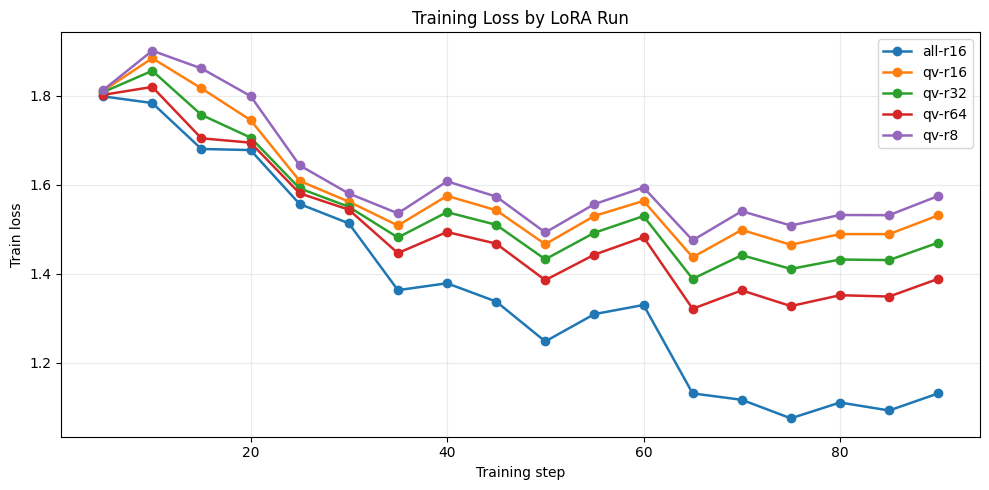

Saved loss curve: /content/lab21_finetune/results/loss_curve.png
Best q/v rank run by eval perplexity: qv-r32
run_id  rank  train_time_min  peak_vram_gb  eval_loss  eval_perplexity
qv-r16  16.0        4.908459      6.237408   1.748971         5.748685
 qv-r8   8.0        4.819755      6.998982   1.760003         5.812456
qv-r32  32.0        4.827955      7.862849   1.745899         5.731052
qv-r64  64.0        4.867138      8.764317   1.752262         5.767633


In [26]:
summary_df = pd.read_csv(RESULTS_DIR / "rank_experiment_summary.csv")
loss_history_df = pd.read_csv(RESULTS_DIR / "loss_history.csv") if (RESULTS_DIR / "loss_history.csv").exists() else pd.DataFrame()

plt.figure(figsize=(10, 5))
if not loss_history_df.empty:
    for run_id, group in loss_history_df.groupby("run_id"):
        group = group.sort_values("step")
        plt.plot(group["step"], group["train_loss"], marker="o", linewidth=1.8, label=run_id)
else:
    print("No training loss history found. Did training run successfully?")
plt.title("Training Loss by LoRA Run")
plt.xlabel("Training step")
plt.ylabel("Train loss")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
loss_curve_path = RESULTS_DIR / "loss_curve.png"
plt.savefig(loss_curve_path, dpi=160, bbox_inches="tight")
plt.show()
print(f"Saved loss curve: {loss_curve_path}")

qv_df = summary_df[summary_df["run_id"].isin(["qv-r8", "qv-r16", "qv-r32", "qv-r64"])].copy()
qv_df["eval_perplexity_numeric"] = pd.to_numeric(qv_df["eval_perplexity"], errors="coerce")
if qv_df["eval_perplexity_numeric"].notna().any():
    best_row = qv_df.loc[qv_df["eval_perplexity_numeric"].idxmin()]
    BEST_RANK_RUN_ID = str(best_row["run_id"])
else:
    BEST_RANK_RUN_ID = "qv-r16"
print(f"Best q/v rank run by eval perplexity: {BEST_RANK_RUN_ID}")
print(qv_df[["run_id", "rank", "train_time_min", "peak_vram_gb", "eval_loss", "eval_perplexity"]].to_string(index=False))

## 8. Qualitative Side-by-Side Evaluation

* 5 prompts có chủ đích, gồm base, `qv-r16`, và best rank nếu best khác `qv-r16`. Cell này generate câu trả lời; cell kế tiếp cho phép bạn chấm thủ công winner/score/comment trước khi save CSV.

In [27]:
TEST_PROMPTS = [
    {
        "prompt_id": "P1",
        "category": "Vietnamese explanation",
        "prompt": "Giải thích khái niệm overfitting trong machine learning cho học sinh lớp 10 bằng tiếng Việt dễ hiểu, kèm một ví dụ ngắn.",
    },
    {
        "prompt_id": "P2",
        "category": "Code generation",
        "prompt": "Viết hàm Python is_prime(n) kiểm tra số nguyên tố. Trả lời bằng code có type hints và 3 test case đơn giản.",
    },
    {
        "prompt_id": "P3",
        "category": "List/format following",
        "prompt": "Liệt kê đúng 5 bước chuẩn bị dataset cho fine-tuning LoRA. Mỗi bước chỉ một dòng, bắt đầu bằng số thứ tự.",
    },
    {
        "prompt_id": "P4",
        "category": "Domain-style Vietnamese answer",
        "prompt": "Bạn là trợ giảng AI. Hãy giải thích ngắn gọn sự khác nhau giữa LoRA và QLoRA cho sinh viên năm nhất ngành AI.",
    },
    {
        "prompt_id": "P5",
        "category": "Edge case / uncertainty",
        "prompt": "Một người nói mô hình của họ đạt perplexity 0.1 trên mọi dữ liệu. Bạn có kết luận mô hình đó chắc chắn tốt không? Trả lời thận trọng và nêu cần kiểm tra gì thêm.",
    },
]

print(f"Qualitative prompts: {len(TEST_PROMPTS)}")
for item in TEST_PROMPTS:
    print(f"{item['prompt_id']} | {item['category']} | {item['prompt']}")

Qualitative prompts: 5
P1 | Vietnamese explanation | Giải thích khái niệm overfitting trong machine learning cho học sinh lớp 10 bằng tiếng Việt dễ hiểu, kèm một ví dụ ngắn.
P2 | Code generation | Viết hàm Python is_prime(n) kiểm tra số nguyên tố. Trả lời bằng code có type hints và 3 test case đơn giản.
P3 | List/format following | Liệt kê đúng 5 bước chuẩn bị dataset cho fine-tuning LoRA. Mỗi bước chỉ một dòng, bắt đầu bằng số thứ tự.
P4 | Domain-style Vietnamese answer | Bạn là trợ giảng AI. Hãy giải thích ngắn gọn sự khác nhau giữa LoRA và QLoRA cho sinh viên năm nhất ngành AI.
P5 | Edge case / uncertainty | Một người nói mô hình của họ đạt perplexity 0.1 trên mọi dữ liệu. Bạn có kết luận mô hình đó chắc chắn tốt không? Trả lời thận trọng và nêu cần kiểm tra gì thêm.


In [28]:
from peft import PeftModel

def build_prompt(prompt):
    return PROMPT_TEMPLATE_NO_INPUT.format(instruction=prompt)

def generate_response(model, tokenizer, prompt, max_new_tokens=220):
    FastLanguageModel.for_inference(model)
    model.eval()
    text = build_prompt(prompt)
    device = next(model.parameters()).device
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=MAX_SEQ_LENGTH).to(device)
    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )
    full = tokenizer.decode(output_ids[0], skip_special_tokens=True)
    if "### Response:" in full:
        answer = full.split("### Response:", 1)[-1].strip()
    else:
        answer = full[len(text):].strip()
    return answer

def generate_outputs_for_model(label, adapter_run_id=None):
    print("=" * 88)
    print(f"Generating qualitative outputs for: {label}")
    print("=" * 88)
    cleanup_cuda(verbose=True)
    model, tokenizer = load_base_model()
    if adapter_run_id:
        adapter_path = ADAPTERS_DIR / adapter_run_id
        assert adapter_path.exists(), f"Adapter not found: {adapter_path}"
        model = PeftModel.from_pretrained(model, str(adapter_path))
        print(f"Loaded adapter: {adapter_path}")

    outputs = {}
    for item in TEST_PROMPTS:
        response = generate_response(model, tokenizer, item["prompt"])
        outputs[item["prompt_id"]] = response
        print(f"\n[{label}] {item['prompt_id']} prompt: {item['prompt']}")
        print(f"[{label}] response:\n{response}\n")

    del model, tokenizer
    cleanup_cuda(verbose=True)
    return outputs

base_outputs = generate_outputs_for_model("base", adapter_run_id=None)
qv_r16_outputs = generate_outputs_for_model("qv-r16", adapter_run_id="qv-r16")

if BEST_RANK_RUN_ID == "qv-r16":
    best_rank_outputs = dict(qv_r16_outputs)
else:
    best_rank_outputs = generate_outputs_for_model(BEST_RANK_RUN_ID, adapter_run_id=BEST_RANK_RUN_ID)

Generating qualitative outputs for: base
CUDA cleanup complete. allocated=4.01 GB | reserved=5.45 GB
==((====))==  Unsloth 2026.5.2: Fast Llama patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

Unsloth: Will load unsloth/Llama-3.2-3B-Instruct-bnb-4bit as a legacy tokenizer.
Both `max_new_tokens` (=220) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_uti


[base] P1 prompt: Giải thích khái niệm overfitting trong machine learning cho học sinh lớp 10 bằng tiếng Việt dễ hiểu, kèm một ví dụ ngắn.
[base] response:
Overfitting là hiện tượng mô hình học tập quá nhiều đặc điểm của dữ liệu huấn luyện, dẫn đến mô hình không thể học tập được những đặc điểm mới trong dữ liệu chưa được huấn luyện. Ví dụ, nếu chúng ta xây dựng một mô hình học tập các bức ảnh của con người, nhưng chỉ sử dụng các bức ảnh của con người có màu trắng, thì mô hình sẽ học tập được đặc điểm màu trắng, nhưng không thể học tập được các đặc điểm màu khác. Do đó, mô hình sẽ không thể dự đoán được các bức ảnh có màu khác. Đây là một ví dụ về overfitting trong machine learning.



Both `max_new_tokens` (=220) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...


[qv-r32] P2 prompt: Viết hàm Python is_prime(n) kiểm tra số nguyên tố. Trả lời bằng code có type hints và 3 test case đơn giản.
[qv-r32] response:
```python
def is_prime(n: int) -> bool:
    if n <= 1:  # 1 và các số nguyên tố nhỏ hơn 1 không phải là nguyên tố
        return False
    for i in range(2, int(n ** 0.5) + 1):  # kiểm tra các ước số từ 2 đến sqrt(n)
        if n % i == 0:  # nếu n có ước số thì nó không phải là nguyên tố
            return False
    return True  # nếu không tìm thấy ước số thì n là nguyên tố
# Test case 1: 2 là nguyên tố
print(is_prime(2))  # Expected output: True

# Test case 2: 15 không phải là nguyên tố
print(is_prime(15))  # Expected output: False

# Test case 3: 17 là nguyên tố
print(is_prime(17))  # Expected output: True
``` ### Response:
Hàm `is_prime(n)` kiểm tra xem số nguyên tố hay không. Nó



Both `max_new_tokens` (=220) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



[qv-r32] P3 prompt: Liệt kê đúng 5 bước chuẩn bị dataset cho fine-tuning LoRA. Mỗi bước chỉ một dòng, bắt đầu bằng số thứ tự.
[qv-r32] response:
1. Xác định mục tiêu của fine-tuning LoRA. 2. Tìm hiểu về dữ liệu. 3. Chọn mô hình. 4. Chuẩn bị dữ liệu. 5. Xác định các tham số. 6. Xác định các tham số. 7. Xác định các tham số. 8. Xác định các tham số. 9. Xác định các tham số. 10. Xác định các tham số. 11. Xác định các tham số. 12. Xác định các tham số. 13. Xác định các tham số. 14. Xác định các tham số. 15. Xác định các tham số. 16. Xác định các tham số. 17. Xác định các tham số. 18. Xác định các tham số. 19. Xác định các tham số. 20. Xác định các tham số. 21. Xác định các tham số. 22. Xác định các tham số



Both `max_new_tokens` (=220) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



[qv-r32] P4 prompt: Bạn là trợ giảng AI. Hãy giải thích ngắn gọn sự khác nhau giữa LoRA và QLoRA cho sinh viên năm nhất ngành AI.
[qv-r32] response:
LoRA và QLoRA là hai thuật ngữ liên quan đến AI, nhưng chúng có ý nghĩa và mục đích khác nhau. LoRA là viết tắt của "Large Language Model for Reasoning", là một loại mô hình ngôn ngữ lớn được thiết kế để xử lý các vấn đề logic và lý luận. Nó được sử dụng để giải quyết các vấn đề logic, như phân tích dữ liệu, lập luận và đưa ra quyết định dựa trên dữ liệu. LoRA được sử dụng rộng rãi trong nhiều lĩnh vực, bao gồm nghiên cứu, kinh doanh và chính phủ. QLoRA là viết tắt của "Quantum Language Model for Reasoning", là một loại mô hình ngôn ngữ lớn được thiết kế để xử lý các vấn đề logic và lý luận bằng cách sử dụng các tính toán lượng tử. QLoRA được sử dụng để giải quyết các vấn đề logic phức tạp và có thể được ứng dụng trong nhiều lĩnh vực, bao gồm nghiên cứu, kinh doanh và chính phủ. Tóm lại, LoRA và QLoRA đều là mô hình ngôn ngữ lớn được thiế

In [29]:
# Review and score qualitative outputs.
# If INTERACTIVE_QUALITATIVE_REVIEW=True, Colab will ask you to type winner/scores/comments.
# Otherwise it writes neutral defaults so the CSV schema is complete; edit REVIEW_OVERRIDES for the final report.

REVIEW_OVERRIDES = {
    # Example:
    # "P1": {"winner": "qv-r16", "score_format": 4, "score_helpfulness": 4, "score_vietnamese_quality": 5, "comment": "Fine-tuned answer is clearer and more structured."},
}

valid_winners = {"base", "qv-r16", "best-rank", "tie"}
qual_rows = []

for item in TEST_PROMPTS:
    pid = item["prompt_id"]
    print("=" * 88)
    print(f"{pid}: {item['prompt']}")
    print("--- base ---")
    print(base_outputs[pid])
    print("--- qv-r16 ---")
    print(qv_r16_outputs[pid])
    print(f"--- best-rank ({BEST_RANK_RUN_ID}) ---")
    print(best_rank_outputs[pid])

    default_review = {
        "winner": "tie",
        "score_format": 3,
        "score_helpfulness": 3,
        "score_vietnamese_quality": 3,
        "comment": "Manual review needed; replace this comment after reading the side-by-side outputs.",
    }
    review = {**default_review, **REVIEW_OVERRIDES.get(pid, {})}

    if INTERACTIVE_QUALITATIVE_REVIEW:
        winner = input("winner [base/qv-r16/best-rank/tie]: ").strip() or review["winner"]
        if winner not in valid_winners:
            winner = "tie"
        review["winner"] = winner
        for key in ["score_format", "score_helpfulness", "score_vietnamese_quality"]:
            value = input(f"{key} [1-5]: ").strip()
            review[key] = int(value) if value else int(review[key])
        comment = input("short comment: ").strip()
        if comment:
            review["comment"] = comment

    qual_rows.append({
        "prompt_id": pid,
        "prompt": item["prompt"],
        "base_output": base_outputs[pid],
        "qv_r16_output": qv_r16_outputs[pid],
        "best_rank_output": best_rank_outputs[pid],
        "winner": review["winner"],
        "score_format": review["score_format"],
        "score_helpfulness": review["score_helpfulness"],
        "score_vietnamese_quality": review["score_vietnamese_quality"],
        "comment": review["comment"],
    })

qual_df = pd.DataFrame(qual_rows)
qual_path = RESULTS_DIR / "qualitative_comparison.csv"
qual_df.to_csv(qual_path, index=False)
print(f"Saved qualitative comparison: {qual_path}")
display(qual_df[["prompt_id", "winner", "score_format", "score_helpfulness", "score_vietnamese_quality", "comment"]])

P1: Giải thích khái niệm overfitting trong machine learning cho học sinh lớp 10 bằng tiếng Việt dễ hiểu, kèm một ví dụ ngắn.
--- base ---
Overfitting là hiện tượng mô hình học tập quá nhiều đặc điểm của dữ liệu huấn luyện, dẫn đến mô hình không thể học tập được những đặc điểm mới trong dữ liệu chưa được huấn luyện. Ví dụ, nếu chúng ta xây dựng một mô hình học tập các bức ảnh của con người, nhưng chỉ sử dụng các bức ảnh của con người có màu trắng, thì mô hình sẽ học tập được đặc điểm màu trắng, nhưng không thể học tập được các đặc điểm màu khác. Do đó, mô hình sẽ không thể dự đoán được các bức ảnh có màu khác. Đây là một ví dụ về overfitting trong machine learning.
--- qv-r16 ---
Overfitting là một vấn đề phổ biến trong machine learning, đặc biệt là khi sử dụng các mô hình phức tạp như hồi quy tuyến tính hoặc mạng thần kinh. Nó xảy ra khi mô hình học được dữ liệu đào tạo quá nhiều và quá phức tạp, dẫn đến mô hình có thể học được các đặc điểm không quan trọng trong dữ liệu và không thể d

,prompt_id,winner,score_format,score_helpfulness,score_vietnamese_quality,comment
0,P1,base,4,5,5,"base trả lời ngắn gọn, dễ hiểu nhất cho học si..."
1,P2,base,3,5,4,"base có code đúng và tối ưu hơn: xử lý n <= 1,..."
2,P3,base,5,3,4,base thắng vì là bản duy nhất tuân thủ đúng fo...
3,P4,qv-r16,3,1,4,qv-r16 là bản “ít sai nhất” vì ít nhất còn đặt...
4,P5,qv-r16,3,4,5,qv-r16 thắng vì trả lời đúng trọng tâm nhất: k...


## 9. Optional: Push Adapters to HuggingFace Hub

khuyến nghị push ít nhất adapter tốt nhất, và mạnh hơn nếu push `qv-r16`, best rank, `all-r16`. Đặt `PUSH_TO_HUB=True`, điền `HF_USERNAME`, login HF, rồi chạy cell này sau training.

In [37]:
from huggingface_hub import HfApi, upload_folder, get_token, login

# This cell requires a HuggingFace token with WRITE permission.
# If you hit 401 Unauthorized: create a fresh token at https://huggingface.co/settings/tokens,
# set it as Colab Secret HF_TOKEN, rerun the HF auth cell, then rerun this upload cell.

def resolve_hf_token_for_upload():
    token = os.environ.get("HF_TOKEN") or os.environ.get("HUGGINGFACE_HUB_TOKEN")
    if token:
        return token
    try:
        from google.colab import userdata
        token = userdata.get("HF_TOKEN")
        if token:
            return token
    except Exception:
        pass
    return get_token()

def safe_repo_slug(text):
    return str(text).replace("_", "-").replace("/", "-").lower()

def adapter_repo_name(run_id):
    if run_id == "qv-r16":
        suffix = "qv-r16"
    elif run_id == BEST_RANK_RUN_ID:
        suffix = "best-rank" if run_id != "qv-r16" else "qv-r16"
    elif run_id == "all-r16":
        suffix = "all-r16"
    else:
        suffix = safe_repo_slug(run_id)
    return f"{HF_REPO_PREFIX}-{suffix}"

def write_model_card(adapter_dir, row, repo_id):
    card = f"""---
base_model: {MODEL_NAME}
library_name: peft
tags:
- lora
- qlora
- unsloth
- vietnamese
- lab21
---

# {repo_id}

LoRA/QLoRA adapter trained for Lab 21 rank experiment.

## Training Setup

- Base model: `{MODEL_NAME}`
- Dataset: `{DATASET_NAME}`
- Sample size after cleaning: {len(ds)}
- Train/eval split: {len(train_ds)}/{len(eval_ds)} with seed {SEED}
- Max sequence length: {MAX_SEQ_LENGTH}
- Epochs: {NUM_EPOCHS}
- Learning rate: {LEARNING_RATE}
- Scheduler: cosine
- Batch size: {TRAIN_BATCH_SIZE}
- Gradient accumulation: {GRAD_ACCUM_STEPS}
- Effective batch size: {TRAIN_BATCH_SIZE * GRAD_ACCUM_STEPS}
- Optimizer: adamw_8bit
- Packing: {PACKING}

## Adapter

- Run ID: `{row['run_id']}`
- Target modules: `{row['target_modules']}`
- Rank: `{row['rank']}`
- Alpha: `{row['alpha']}`
- Trainable parameters: `{row['trainable_params']}`
- Trainable percent: `{row['trainable_percent']}`

## Evaluation

- Eval loss: `{row['eval_loss']}`
- Eval perplexity: `{row['eval_perplexity']}`
- Peak VRAM GB: `{row['peak_vram_gb']}`
- Train time minutes: `{row['train_time_min']}`

See the GitHub/Colab report for qualitative comparisons and rank trade-off analysis.
"""
    (adapter_dir / "README.md").write_text(card, encoding="utf-8")

if not PUSH_TO_HUB:
    print("PUSH_TO_HUB=False. Set it to True after HF login to upload adapters.")
else:
    hf_token = resolve_hf_token_for_upload()
    assert hf_token, "No HF token found. Set Colab secret HF_TOKEN or run notebook_login() before uploading."

    login(token=hf_token, add_to_git_credential=False)
    api = HfApi(token=hf_token)
    try:
        who = api.whoami(token=hf_token)
    except Exception as exc:
        raise RuntimeError(
            "HF authentication failed. Your token is missing/invalid or lacks permission. "
            "Create a token with WRITE permission and set it as Colab secret HF_TOKEN."
        ) from exc

    authenticated_user = who.get("name")
    namespace = HF_USERNAME
    if not namespace or "TODO" in str(namespace):
        namespace = authenticated_user
    print(f"HF auth OK. Authenticated user: {authenticated_user}")
    print(f"Uploading repos under namespace: {namespace}")

    summary_df = pd.read_csv(RESULTS_DIR / "rank_experiment_summary.csv")
    upload_run_ids = ["qv-r16", BEST_RANK_RUN_ID, "all-r16"]
    upload_run_ids = list(dict.fromkeys(upload_run_ids))

    for run_id in upload_run_ids:
        adapter_dir = ADAPTERS_DIR / run_id
        if not adapter_dir.exists():
            print(f"Skip {run_id}: adapter folder missing at {adapter_dir}")
            continue
        row_match = summary_df[summary_df["run_id"] == run_id]
        if row_match.empty:
            print(f"Skip {run_id}: no metrics row found in summary CSV")
            continue
        row = row_match.iloc[0].to_dict()
        repo_name = adapter_repo_name(run_id)
        repo_id = f"{namespace}/{repo_name}"
        write_model_card(adapter_dir, row, repo_id)
        try:
            api.create_repo(repo_id=repo_id, repo_type="model", private=HF_PRIVATE_REPOS, exist_ok=True, token=hf_token)
            upload_folder(repo_id=repo_id, folder_path=str(adapter_dir), repo_type="model", token=hf_token)
        except Exception as exc:
            raise RuntimeError(
                f"Failed to upload {run_id} to {repo_id}. Check that the token has WRITE permission "
                "and that you can create repos in this namespace."
            ) from exc
        url = f"https://huggingface.co/{repo_id}"
        hub_urls[run_id] = url
        print(f"Uploaded {run_id}: {url}")

    # Update summary CSV with Hub URLs.
    summary_df["hf_adapter_url"] = summary_df.apply(lambda row: hub_urls.get(row["run_id"], row.get("hf_adapter_url", "")), axis=1)
    summary_df.to_csv(RESULTS_DIR / "rank_experiment_summary.csv", index=False)
    print("Updated rank_experiment_summary.csv with HF URLs.")

HF auth OK. Authenticated user: DangMinh21
Uploading repos under namespace: DangMinh21


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  .../tokenizer/tokenizer.json: 100%|##########| 17.2MB / 17.2MB            

  ...ers/qv-r16/tokenizer.json: 100%|##########| 17.2MB / 17.2MB            

...

  .../tokenizer/tokenizer.json: 100%|##########| 17.2MB / 17.2MB            

  ...rs/all-r16/tokenizer.json: 100%|##########| 17.2MB / 17.2MB            

  ...adapter_model.safetensors:   0%|          | 45.8kB / 97.3MB            

  ...all-r16/training_args.bin:   2%|1         |   102B / 5.58kB            

Uploaded all-r16: https://huggingface.co/DangMinh21/VinUni-lab21-Finetuning-w-LoRA-QLoRA-all-r16
Updated rank_experiment_summary.csv with HF URLs.


## 10. Generate REPORT.md and LINKS.md Drafts

Cell này tạo bản nháp có đủ 6 sections bắt buộc. Sau khi chạy xong, bạn cần đọc lại, bổ sung nhận xét thực tế, và bảo đảm conclusion >= 100 từ.

In [38]:
def markdown_table(df, columns):
    if df.empty:
        return "No rows available."
    return df[columns].to_markdown(index=False)

def safe_float_sum(series):
    return pd.to_numeric(series, errors="coerce").fillna(0).sum()

summary_df = pd.read_csv(RESULTS_DIR / "rank_experiment_summary.csv")
qual_df = pd.read_csv(RESULTS_DIR / "qualitative_comparison.csv") if (RESULTS_DIR / "qualitative_comparison.csv").exists() else pd.DataFrame()

total_train_minutes = safe_float_sum(summary_df.get("train_time_min", pd.Series(dtype=float)))
estimated_t4_cost = total_train_minutes / 60.0 * 0.35
wandb_links = summary_df["wandb_run_url"].dropna().astype(str)
wandb_links = [x for x in wandb_links if x and x != "nan"]
hf_links = summary_df["hf_adapter_url"].dropna().astype(str)
hf_links = [x for x in hf_links if x and x != "nan"]

rank_table_cols = [
    "run_id", "target_modules", "rank", "alpha", "trainable_params", "trainable_percent",
    "train_time_min", "peak_vram_gb", "eval_loss", "eval_perplexity", "final_train_loss", "notes",
]
rank_table_cols = [c for c in rank_table_cols if c in summary_df.columns]
rank_table_md = markdown_table(summary_df, rank_table_cols)

qual_md_parts = []
for _, row in qual_df.iterrows():
    qual_md_parts.append(f"""
### {row['prompt_id']}

**Prompt:** {row['prompt']}

| Model | Output |
|---|---|
| Base | {str(row['base_output']).replace('|', '/')} |
| qv-r16 | {str(row['qv_r16_output']).replace('|', '/')} |
| Best rank ({BEST_RANK_RUN_ID}) | {str(row['best_rank_output']).replace('|', '/')} |

Winner: `{row['winner']}`. Format: {row['score_format']}/5, helpfulness: {row['score_helpfulness']}/5, Vietnamese quality: {row['score_vietnamese_quality']}/5.

Comment: {row['comment']}
""")
qual_md = "\n".join(qual_md_parts) if qual_md_parts else "Qualitative comparison not generated yet."

report = f"""# Lab 21 Report - LoRA/QLoRA Rank Experiment

Student: {STUDENT_NAME}
Student ID: {STUDENT_ID}
Submission option: Option B - GitHub + HuggingFace Hub

## 1. Setup

- Base model: `{MODEL_NAME}`
- Dataset: `{DATASET_NAME}`
- Sample size after cleaning: {len(ds)}
- Train/eval split: {len(train_ds)}/{len(eval_ds)}, seed `{SEED}`
- Token p95: {p95}
- Max sequence length: {MAX_SEQ_LENGTH}
- GPU: {gpu_name}, {gpu_vram_gb:.2f} GB VRAM
- Epochs: {NUM_EPOCHS}
- Learning rate: {LEARNING_RATE}
- Scheduler: cosine
- Batch size: {TRAIN_BATCH_SIZE}; gradient accumulation: {GRAD_ACCUM_STEPS}; effective batch size: {TRAIN_BATCH_SIZE * GRAD_ACCUM_STEPS}
- Optimizer: adamw_8bit
- Packing: {PACKING}
- Total training time: {total_train_minutes:.2f} minutes
- Estimated T4 cost at $0.35/hour: ${estimated_t4_cost:.2f}
- GitHub: {GITHUB_REPO_URL}
- Colab: {COLAB_NOTEBOOK_URL}
- W&B links: {', '.join(wandb_links) if wandb_links else 'Not available or W&B disabled'}
- HF adapter links: {', '.join(hf_links) if hf_links else 'Not uploaded yet'}

## 2. Rank Experiment Results

{rank_table_md}

Initial observations to finalize after reviewing results:

- Best q/v rank by eval perplexity: `{BEST_RANK_RUN_ID}`.
- Compare `qv-r16` and `all-r16` to discuss whether targeting all layers improved quality enough to justify extra parameters/time/VRAM.
- Compare `qv-r32` and `qv-r64` to discuss diminishing returns.

## 3. Loss Curve Analysis

Loss curve file: `results/loss_curve.png`
Token length plot: `results/token_length_distribution.png`

Write your analysis here after inspecting the plot. Mention whether train loss decreases smoothly, whether there are noisy spikes, and that eval-during-training was disabled by design on T4. Final eval loss/perplexity was computed manually after each run on the same eval set.

## 4. Qualitative Comparison

{qual_md}

## 5. Conclusion về Rank Trade-off

TODO: Replace this paragraph with at least 100 words based on your actual numbers. A reasonable structure is: state the best rank on this dataset, explain the cost/quality trade-off, discuss whether r=32 shows diminishing returns before r=64, explain when r=8/r=16/r=32/r=64 should be chosen in production, and compare all-layers with q/v-only at r=16. Be honest if eval set is small or qualitative outputs show mixed results.

## 6. What I Learned

- TODO: Explain how LoRA rank changes trainable capacity, time, and VRAM.
- TODO: Explain why perplexity and qualitative examples answer different evaluation questions.
- TODO: Explain how QLoRA makes adapter fine-tuning feasible on a free T4 GPU.
"""

REPORT_PATH.write_text(report, encoding="utf-8")
print(f"Wrote report draft: {REPORT_PATH}")

links = f"""# Lab 21 Links

- GitHub repository: {GITHUB_REPO_URL}
- Colab notebook: {COLAB_NOTEBOOK_URL}

## HuggingFace Hub Adapters

{chr(10).join('- ' + x for x in hf_links) if hf_links else '- Not uploaded yet'}

## W&B Runs

{chr(10).join('- ' + x for x in wandb_links) if wandb_links else '- Not available or W&B disabled'}
"""
LINKS_PATH.write_text(links, encoding="utf-8")
print(f"Wrote links file: {LINKS_PATH}")

Wrote report draft: /content/lab21_finetune/REPORT.md
Wrote links file: /content/lab21_finetune/LINKS.md


## 11. Package Artifacts for Download/GitHub

Cell này gom các file cần nộp vào zip nhẹ: report, links, CSV, plots. Adapter weights có thể nằm trên HF Hub.

In [39]:
# Create a lightweight submission archive for GitHub/upload.
archive_base = OUTPUT_DIR / "lab21_submission_artifacts"
archive_dir = Path(str(archive_base))
if archive_dir.exists():
    shutil.rmtree(archive_dir)
archive_dir.mkdir(parents=True, exist_ok=True)

# Copy key files.
for src in [REPORT_PATH, LINKS_PATH]:
    if src.exists():
        shutil.copy2(src, archive_dir / src.name)

results_archive_dir = archive_dir / "results"
results_archive_dir.mkdir(exist_ok=True)
for filename in ["rank_experiment_summary.csv", "loss_history.csv", "qualitative_comparison.csv", "loss_curve.png", "token_length_distribution.png"]:
    src = RESULTS_DIR / filename
    if src.exists():
        shutil.copy2(src, results_archive_dir / filename)

requirements_text = """unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git
trl>=0.12,<0.16
peft
accelerate
bitsandbytes
datasets
matplotlib
seaborn
pandas
numpy
wandb
huggingface_hub
tabulate
"""
(archive_dir / "requirements.txt").write_text(requirements_text, encoding="utf-8")

zip_path = shutil.make_archive(str(archive_base), "zip", root_dir=str(archive_dir))
print(f"Created archive: {zip_path}")
print("Archive contents:")
for path in sorted(archive_dir.rglob("*")):
    print(" -", path.relative_to(archive_dir))

try:
    from google.colab import files
    print("Use files.download(zip_path) if you want an immediate browser download.")
except Exception:
    pass

Created archive: /content/lab21_finetune/lab21_submission_artifacts.zip
Archive contents:
 - LINKS.md
 - REPORT.md
 - requirements.txt
 - results
 - results/loss_curve.png
 - results/loss_history.csv
 - results/qualitative_comparison.csv
 - results/rank_experiment_summary.csv
 - results/token_length_distribution.png
Use files.download(zip_path) if you want an immediate browser download.


## 12. Final Checklist

Before submitting, verify:

- `qv-r8`, `qv-r16`, `qv-r64` trained, saved, evaluated.
- `qv-r32` trained for diminishing returns bonus.
- `all-r16` trained for all-layers bonus, or limitation documented if OOM.
- `results/rank_experiment_summary.csv` has the required columns including base row.
- `results/qualitative_comparison.csv` has 5 prompts and reviewed scores/comments.
- `results/loss_curve.png` and `results/token_length_distribution.png` are saved.
- HF Hub adapters are uploaded if using Option B.
- `REPORT.md` has exactly 6 sections and conclusion >= 100 words.
- `LINKS.md` contains GitHub, HF Hub, W&B, and Colab links where available.